<a href="https://colab.research.google.com/github/Maanvijangir/Lung-Cancer-Predictive-System/blob/main/cancer_cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json

In [ ]:
kaggle_username = "maanvijangir",
kaggle_key = "KGAT_28319db51281a235cef604e97d0af9a8"

In [ ]:
kaggle_json = {"username": kaggle_username, "key": kaggle_key}
with open("kaggle.json", "w") as f:
  json.dump(kaggle_json, f)

In [ ]:
!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
!unzip lung-and-colon-cancer-histopathological-images.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc10.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc100.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1000.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1001.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1002.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1003.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1004.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1005.jpeg  
  inflating: /content/dataset/lung_colon_image_set/lung_image_sets/lung_scc/lungscc1006.jpeg  
  inf

In [ ]:
import os, shutil
from sklearn.model_selection import train_test_split

data_dir = "/content/dataset/lung_colon_image_set"
base_dir = "/content/split_data"
os.makedirs(base_dir, exist_ok=True)

In [ ]:
def get_all_images(path):
  files=[]
  for root, dirs, filenames in os.walk(path):
    for f in filenames:
      if f.lower().endswith(('.png','.jpg','.jpeg')):
        files.append(os.path.join(root, f))
  return files

In [ ]:
for category in os.listdir(data_dir):
  category_path = os.path.join(data_dir, category)
  if os.path.isdir(category_path):
    images = get_all_images(category_path)

    if len(images) == 0:
      print(f" No images found in {category_path}, Skipping...")
      continue

    train, test = train_test_split(images, test_size=0.2, random_state=42)

    for split, split_images in zip(["train", "test"], [train, test]):
      split_path = os.path.join(base_dir, split, category)
      os.makedirs(split_path, exist_ok=True)
      for img in split_images:
        shutil.copy(img, os.path.join(split_path, os.path.basename(img)))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root="split_data/train", transform=transform)
test_data  = datasets.ImageFolder(root="split_data/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:",train_data.classes)


Classes: ['colon_image_sets', 'lung_image_sets']


In [ ]:
class LungCancerCNN(nn.Module):
    def __init__(self, num_classes):
        super(LungCancerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

num_classes = len(train_data.classes)
model = LungCancerCNN(num_classes).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

for epoch in range(5):  # adjust epochs
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    acc = correct / len(train_data)
    print(f"Epoch {epoch+15}, Loss: {running_loss:.3f}, Train Acc: {acc:.4f}")


Epoch 1, Loss: 90.461, Train Acc: 0.9443
Epoch 2, Loss: 30.694, Train Acc: 0.9833
Epoch 3, Loss: 23.468, Train Acc: 0.9879
Epoch 4, Loss: 18.454, Train Acc: 0.9897
Epoch 5, Loss: 17.542, Train Acc: 0.9913


In [ ]:
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()

test_acc = correct / len(test_data)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Test Accuracy: 99.42%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
torch.save(model, "/content/drive/MyDrive/cancer_cnn_model2.pth")

In [ ]:
def predict_image(img_path, model, classes):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img)
        _, predicted = torch.max(outputs, 1)
    return classes[predicted.item()]

pred_class = predict_image("/content/split_data/test/colon_image_sets/colonca1037.jpeg", model, train_data.classes)
print("Predicted:", pred_class)

Predicted: colon_image_sets


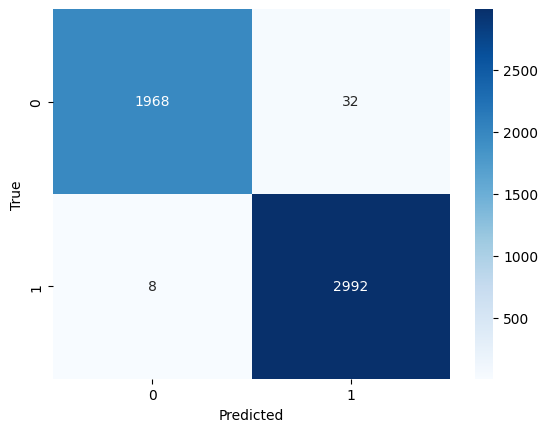

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Collect predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate classification report
print(classification_report(all_labels, all_preds, target_names=train_data.classes))



                  precision    recall  f1-score   support

colon_image_sets       1.00      0.99      0.99      2000
 lung_image_sets       0.99      1.00      1.00      3000

        accuracy                           1.00      5000
       macro avg       1.00      0.99      0.99      5000
    weighted avg       1.00      1.00      1.00      5000



In [ ]:
from sklearn.model_selection import KFold
def get_kfold_indices(dataset, k=5, shuffle=True, random_state=42):
    kf = KFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    folds = []
    for train_idx, val_idx in kf.split(range(len(dataset))):
        folds.append((train_idx, val_idx))
    return folds

In [ ]:
folds = get_kfold_indices(train_data, k=5)

for fold, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold+1}: Train size={len(train_idx)}, Val size={len(val_idx)}")
    # Use train_idx and val_idx with Subset(dataset, train_idx/val_idx)


Fold 1: Train size=16000, Val size=4000
Fold 2: Train size=16000, Val size=4000
Fold 3: Train size=16000, Val size=4000
Fold 4: Train size=16000, Val size=4000
Fold 5: Train size=16000, Val size=4000


In [ ]:

def train_and_evaluate(train_subset, val_subset, model_class, num_classes, device, epochs=5, batch_size=32):

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Define model, loss, optimizer
    model = model_class(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Training loop
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
    val_acc = val_correct / len(val_subset)
    return val_acc


In [ ]:
folds = get_kfold_indices(train_data, k=5)

results = run_kfold(
    train_data,
    folds,
    lambda train_subset, val_subset: train_and_evaluate(train_subset, val_subset, LungCancerCNN, num_classes, device)
)



--- Fold 1 ---
Fold 1 Validation Accuracy: 0.9970

--- Fold 2 ---
Fold 2 Validation Accuracy: 0.9875

--- Fold 3 ---
Fold 3 Validation Accuracy: 0.9892

--- Fold 4 ---
Fold 4 Validation Accuracy: 0.9930

--- Fold 5 ---
Fold 5 Validation Accuracy: 0.9915

Cross-validation results: [0.997, 0.9875, 0.98925, 0.993, 0.9915]
Average Validation Accuracy: 0.9916499999999999
